# MIDI Analysis Agenda: MAESTRO vs. Genre vs. Random
Get the MAESTRO/test, Random set and Genre set, and look at the distributions of:

1. Note durations
2. Note pitches
3. Note velocities
4. Polyphony degrees' durations

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pretty_midi as pm
import matplotlib.pyplot as plt

from tqdm import tqdm

import sys
sys.path.append('..')
from utils import find_files, get_polyphony_degrees

In [2]:
midisets = ['1_genre', '2_random', '3_maetest']
pm_objects = {}
for midiset in midisets:
    path_true = f'../data/{midiset}'
    sorted_paths_true = find_files(path_true, '*.mid')
    pm_objects[midiset] = [pm.PrettyMIDI(midi_fpath) for midi_fpath in tqdm(sorted_paths_true)]

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:01<00:00, 10.29it/s]


## Note Durations

In [3]:
def get_note_durations(instrument):
    note_durations = []
    for note in instrument.notes:
        note_durations.append(note.duration)
    return note_durations

note_durations = {}
for midiset in midisets:
    note_durations[midiset] = sum([sum([get_note_durations(inst) for inst in pm_object.instruments], [])
                                   for pm_object in tqdm(pm_objects[midiset])], [])

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 1380.75it/s]


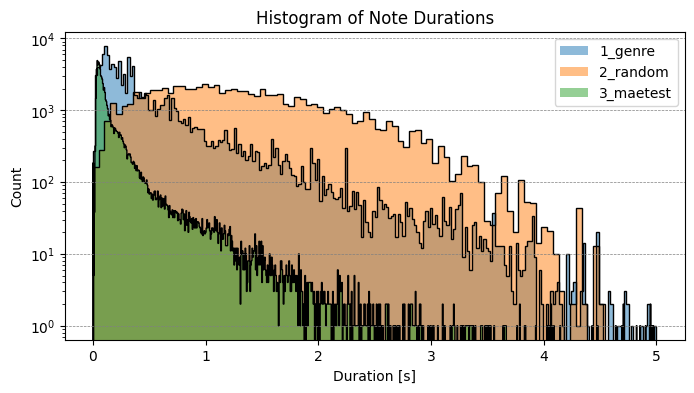

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
log = True; alpha = 0.5; bins = [200, 'auto'][1]

for midiset in midisets:
    durations = note_durations[midiset]
    ax.hist(durations, bins=bins, log=log, range=[0, 5], histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(durations, bins=bins, log=log, range=[0, 5], histtype='step', linewidth=1.0, color='black')

if log:
    # Add horizontal dashed lines for each order of magnitude step on the y-axis
    orders_of_mag = np.floor(np.log10(ax.get_ylim()[1]))
    y_ticks = np.logspace(0, orders_of_mag, num=int(orders_of_mag)+1)
    for y in y_ticks:
        ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5)

plt.title('Histogram of Note Durations')
plt.xlabel('Duration [s]')
plt.ylabel('Count')
plt.legend()
plt.show()

## Note Pitches

In [5]:
def get_note_pitches(instrument):
    note_pitches = []
    for note in instrument.notes:
        note_pitches.append(note.pitch)
    return note_pitches

note_pitches = {}
for midiset in midisets:
    note_pitches[midiset] = sum([sum([get_note_pitches(inst) for inst in pm_object.instruments], [])
                                for pm_object in tqdm(pm_objects[midiset])], [])

100%|██████████| 20/20 [00:00<00:00, 3937.20it/s]


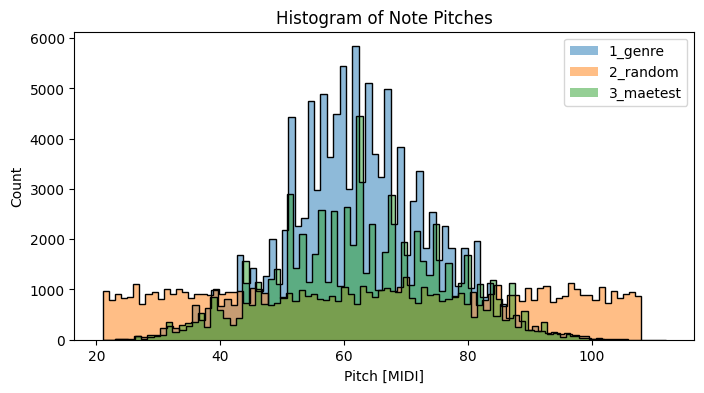

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
log = False; alpha = 0.5;

for midiset in midisets:
    pitches = note_pitches[midiset]
    ax.hist(pitches, bins=len(np.unique(pitches)), log=log, histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(pitches, bins=len(np.unique(pitches)), log=log, histtype='step', linewidth=1.0, color='black')

plt.title('Histogram of Note Pitches')
plt.xlabel('Pitch [MIDI]')
plt.ylabel('Count')
plt.legend()
plt.show()

## Note Velocities

In [7]:
def get_note_velocities(instrument):
    note_velocities = []
    for note in instrument.notes:
        note_velocities.append(note.velocity)
    return note_velocities

note_velocities = {}
for midiset in midisets:
    note_velocities[midiset] = sum([sum([get_note_velocities(inst) for inst in pm_object.instruments], [])
                                    for pm_object in tqdm(pm_objects[midiset])], [])

100%|██████████| 20/20 [00:00<00:00, 3984.14it/s]


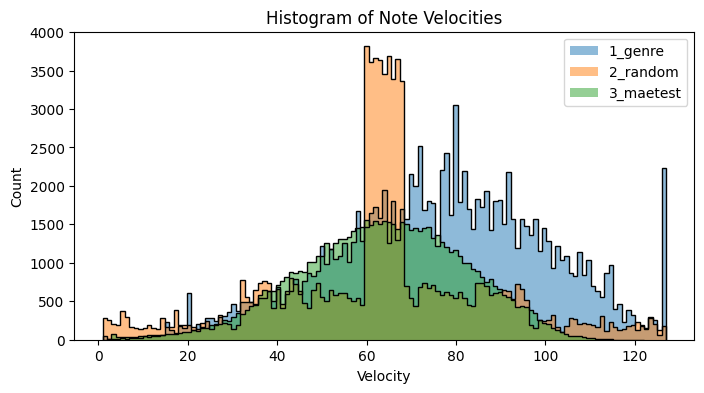

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
log = False; alpha = 0.5;

for midiset in midisets:
    velocities = note_velocities[midiset]
    ax.hist(velocities, bins=max(velocities)-min(velocities)+1, log=log, histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(velocities, bins=max(velocities)-min(velocities)+1, log=log, histtype='step', linewidth=1.0, color='black')

plt.title('Histogram of Note Velocities')
plt.xlabel('Velocity')
plt.ylabel('Count')
plt.legend()
plt.show()

## Polyphony Degrees

Histogram of Occurences (and/or Durations) of different Degrees of Polyphony

In [9]:
fs = 10
set_polyphonies = {}
for midiset in midisets:
    set_polyphonies[midiset] = list(np.concatenate([np.concatenate([get_polyphony_degrees(inst, fs=fs, events_only=False) for inst in pm_object.instruments])
                                                    for pm_object in tqdm(pm_objects[midiset])]))

100%|██████████| 20/20 [00:00<00:00, 94.78it/s]


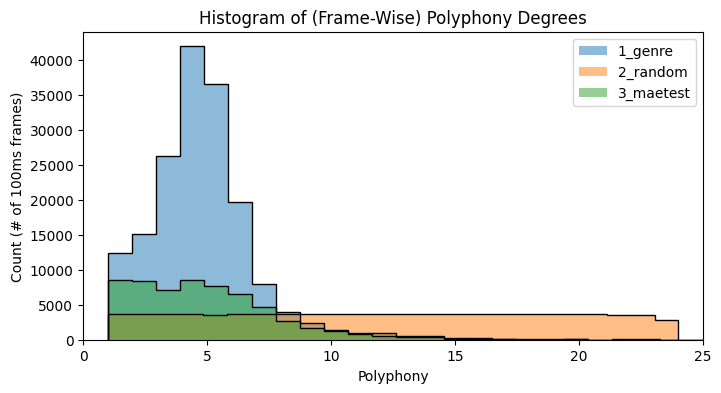

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
log = False; alpha = 0.5;

for midiset in midisets:
    polyphonies = set_polyphonies[midiset]
    ax.hist(polyphonies, bins=max(polyphonies)-min(polyphonies)+1, log=log, histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(polyphonies, bins=max(polyphonies)-min(polyphonies)+1, log=log, histtype='step', linewidth=1.0, color='black')

plt.xlim(0, 25)
plt.title('Histogram of (Frame-Wise) Polyphony Degrees')
plt.xlabel('Polyphony')
plt.ylabel(f'Count (# of {int(1000/fs)}ms frames)')
plt.legend()
plt.show()

## All in one: Durations, Pitches, Velocities, Polyphony

### Figure 5

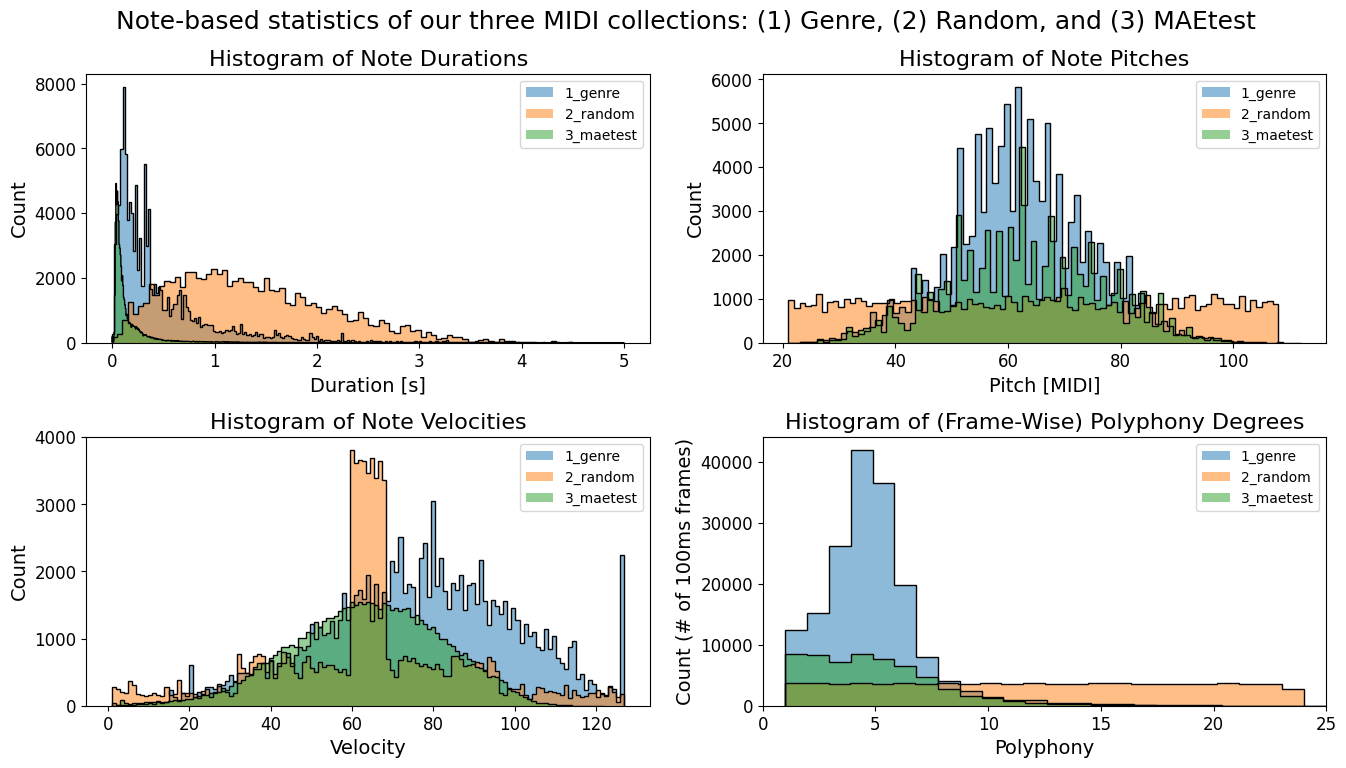

In [11]:
# single figure with all 4 histograms as subplots on a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw={'wspace': 0.20, 'hspace': 0.35})
alpha = 0.5

fs_title=16
fs_axis=14
fs_ticks=12

# Note Durations
log_dur = False; 
bin_dur = 'auto'
ax = axs.reshape(-1)[0]

for midiset in midisets:
    durations = note_durations[midiset]
    ax.hist(durations, bins=bin_dur, log=log_dur, range=[0, 5], histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(durations, bins=bin_dur, log=log_dur, range=[0, 5], histtype='step', linewidth=1.0, color='black')

if log_dur:
    # Add horizontal dashed lines for each order of magnitude step on the y-axis
    orders_of_mag = np.floor(np.log10(ax.get_ylim()[1]))
    y_ticks = np.logspace(0, orders_of_mag, num=int(orders_of_mag)+1)
    for y in y_ticks:
        ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5)

ax.set_title('Histogram of Note Durations', fontsize=fs_title)
ax.set_xlabel('Duration [s]', fontsize=fs_axis)
ax.set_ylabel('Count', fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)
ax.legend()

# Note Pitches
log_pitch = False
ax = axs.reshape(-1)[1]

for midiset in midisets:
    pitches = note_pitches[midiset]
    ax.hist(pitches, bins=len(np.unique(pitches)), log=log_pitch, histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(pitches, bins=len(np.unique(pitches)), log=log_pitch, histtype='step', linewidth=1.0, color='black')

ax.set_title('Histogram of Note Pitches', fontsize=fs_title)
ax.set_xlabel('Pitch [MIDI]', fontsize=fs_axis)
ax.set_ylabel('Count', fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)
ax.legend()

# Note Velocities
log_vel = False
ax = axs.reshape(-1)[2]

for midiset in midisets:
    velocities = note_velocities[midiset]
    ax.hist(velocities, bins=max(velocities)-min(velocities)+1, log=log_vel, histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(velocities, bins=max(velocities)-min(velocities)+1, log=log_vel, histtype='step', linewidth=1.0, color='black')

ax.set_title('Histogram of Note Velocities', fontsize=fs_title)
ax.set_xlabel('Velocity', fontsize=fs_axis)
ax.set_ylabel('Count', fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)
ax.legend()

# Polyphony Degrees
log_poly = False
ax = axs.reshape(-1)[3]

for midiset in midisets:
    polyphonies = set_polyphonies[midiset]
    ax.hist(polyphonies, bins=max(polyphonies)-min(polyphonies)+1, log=log_poly, histtype='bar', alpha=alpha, label=midiset, density=False)
    ax.hist(polyphonies, bins=max(polyphonies)-min(polyphonies)+1, log=log_poly, histtype='step', linewidth=1.0, color='black')

ax.set_xlim(0, 25)
ax.set_title('Histogram of (Frame-Wise) Polyphony Degrees', fontsize=fs_title)
ax.set_xlabel('Polyphony', fontsize=fs_axis)
ax.set_ylabel(f'Count (# of {int(1000/fs)}ms frames)', fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)
ax.legend()

fig.suptitle('Note-based statistics of our three MIDI collections: (1) Genre, (2) Random, and (3) MAEtest', fontsize=fs_title+2)
plt.subplots_adjust(top=0.90)

# fig.savefig('../paper/figs/datastats_midi_all_juxtaposed.pdf', bbox_inches='tight')

## Compare sizes of the three subsets (hours, notes, pieces)

### Table 2

In [12]:
for midiset in midisets:
    total_duration_sec = sum([pm_object.get_end_time() for pm_object in pm_objects[midiset]])
    total_duration_min = total_duration_sec / 60
    total_duration_hr = total_duration_min / 60
    print(f'{midiset}: {total_duration_hr:.2f} hours')

1_genre: 5.25 hours
2_random: 2.40 hours
3_maetest: 1.84 hours


In [14]:
for midiset in midisets:
    # get all notes from all instruments in all midis in the current midiset
    total_note_count = len(sum([sum([inst.notes for inst in pm_object.instruments], []) for pm_object in pm_objects[midiset]], []))
    print(f'{midiset}: {total_note_count} notes')

1_genre: 118388 notes
2_random: 79054 notes
3_maetest: 73060 notes


Measure MAEtest in time first / inspect the weirdness

In [16]:
import pandas as pd
import pretty_midi as pm
import librosa
import sys
sys.path.append('..')
from utils import find_files

df = pd.read_csv('../tri24/data/meta_csv/meta_maestro_subset.csv')

midi_durations = []
for subpath in df[df['split']=='test']['midi_path'].tolist():
    midi_durations.append(pm.PrettyMIDI(f'../data/mae/maestro-v3.0.0/{subpath}').get_end_time())

total_duration_sec = sum(midi_durations)
total_duration_min = total_duration_sec / 60
total_duration_hr = total_duration_min / 60
print(f'MAEtest (MAESTRO MIDI): {total_duration_hr:.2f} hours')

audio_durations = []
for subpath in df[df['split']=='test']['audio_path'].tolist():
    y, sr = librosa.load(f'../data/mae/maestro-v3.0.0/{subpath}')
    audio_durations.append(len(y) / sr)

total_duration_sec = sum(audio_durations)
total_duration_min = total_duration_sec / 60
total_duration_hr = total_duration_min / 60
print(f'MAEtest (MAESTRO audio): {total_duration_hr:.2f} hours')

midi_durations = []
for subpath in df[df['split']=='test']['midi_performance'].tolist():
    midi_durations.append(pm.PrettyMIDI(f'../tri24/data/maestro_subset/test/{subpath}').get_end_time())

total_duration_sec = sum(midi_durations)
total_duration_min = total_duration_sec / 60
total_duration_hr = total_duration_min / 60
print(f'MAEtest (tri24_zenodo MIDI): {total_duration_hr:.2f} hours')

maetest_wavs_dk = find_files('../data/dk/3_maetest_dk', '*.wav')
maetest_durations_sec = []
for filepath in maetest_wavs_dk:
    y, sr = librosa.load(filepath)
    maetest_durations_sec.append(len(y) / sr)
total_maetest_duration_sec = sum(maetest_durations_sec)
print(f'MAEtest (tri24_zenodo audio Disklavier): {(total_maetest_duration_sec)/(60*60):.2f} hours')

maetest_wavs_orig = find_files('../data/mae/3_maetest_mae', '*.wav')
maetest_durations_sec = []
for filepath in maetest_wavs_orig:
    y, sr = librosa.load(filepath)
    maetest_durations_sec.append(len(y) / sr)
total_maetest_duration_sec = sum(maetest_durations_sec)
print(f'MAEtest (tri24_zenodo audio ORIGINAL): {(total_maetest_duration_sec)/(60*60):.2f} hours')

MAEtest (MAESTRO MIDI): 3.47 hours
MAEtest (MAESTRO audio): 3.47 hours
MAEtest (tri24_zenodo MIDI): 1.84 hours
MAEtest (tri24_zenodo audio Disklavier): 1.86 hours
MAEtest (tri24_zenodo audio ORIGINAL): 1.85 hours


In [28]:
df_maestro = pd.read_csv('../data/mae/maestro-v3.0.0.csv')

maefull_maestro_midi_note_count = 0
for subpath in df_maestro[df_maestro['split']=='test']['midi_filename'].tolist():
    pm_object = pm.PrettyMIDI(f'../data/mae/maestro-v3.0.0/{subpath}')
    note_count = len(sum([inst.notes for inst in pm_object.instruments], []))
    maefull_maestro_midi_note_count += note_count

print(f'MAEfull -- 100% MAESTRO/test -- (MAESTRO MIDI): {maefull_maestro_midi_note_count} notes')

maetest_maestro_midi_note_count = 0
for subpath in df[df['split']=='test']['midi_path'].tolist():
    pm_object = pm.PrettyMIDI(f'../data/mae/maestro-v3.0.0/{subpath}')
    note_count = len(sum([inst.notes for inst in pm_object.instruments], []))
    maetest_maestro_midi_note_count += note_count

print(f'MAEtest (MAESTRO MIDI): {maetest_maestro_midi_note_count} notes')

maetest_tri24zenodo_midi_note_count = 0
for subpath in df[df['split']=='test']['midi_performance'].tolist():
    pm_object = pm.PrettyMIDI(f'../tri24/data/maestro_subset/test/{subpath}')
    note_count = len(sum([inst.notes for inst in pm_object.instruments], []))
    maetest_tri24zenodo_midi_note_count += note_count

print(f'MAEtest (tri24_zenodo MIDI): {maetest_tri24zenodo_midi_note_count} notes')

MAEfull -- 100% MAESTRO/test -- (MAESTRO MIDI): 741410 notes
MAEtest (MAESTRO MIDI): 124815 notes
MAEtest (tri24_zenodo MIDI): 73060 notes


In [30]:
df = pd.read_csv('../data/mae/maestro-v3.0.0.csv')
mae3_durations = df.groupby('split').agg({'split': 'count', 'duration': lambda x: ((x / 60) / 60).sum()})

df = pd.read_csv('../tri24/data/meta_csv/meta_maestro_subset.csv')
mae_dk_durations = df.rename(columns={'duration_sec': 'duration'}).groupby('split').agg({'split': 'count', 'duration': lambda x: ((x / 60) / 60).sum()})

n_pieces_maestro_test = mae3_durations.loc['test', 'split']
n_pieces_mae_dk_test_subset = mae_dk_durations.loc['test', 'split']

n_hours_maestro_test = mae3_durations.loc['test', 'duration']
# n_hours_mae_dk_test_subset = mae_dk_durations.loc['test', 'duration'] # wrong!
n_hours_mae_dk_test_subset = total_maetest_duration_sec / (60**2)

print(f'Number of pieces in MAESTRO test set: {n_pieces_maestro_test}')
print(f'Number of pieces in our Disklavier-rendered subset of MAESTRO test set: {n_pieces_mae_dk_test_subset}')
print(f'That is {100 * n_pieces_mae_dk_test_subset / n_pieces_maestro_test:.2f}% ({n_pieces_mae_dk_test_subset} out of {n_pieces_maestro_test})')
print(f'Number of hours in MAESTRO test set: {n_hours_maestro_test:.2f}')
print(f'Number of hours in our Disklavier-rendered subset of MAESTRO test set: {n_hours_mae_dk_test_subset:.2f}')
print(f'That is {100 * n_hours_mae_dk_test_subset / n_hours_maestro_test:.2f}% ({n_hours_mae_dk_test_subset:.2f} out of {n_hours_maestro_test:.2f})')
print(f'Number of notes in MAESTRO test set: {maefull_maestro_midi_note_count}')
print(f'Number of notes in our Disklavier-rendered subset of MAESTRO test set: {maetest_tri24zenodo_midi_note_count}')
print(f'That is {100 * maetest_tri24zenodo_midi_note_count / maefull_maestro_midi_note_count:.2f}% '+
      f'({maetest_tri24zenodo_midi_note_count} out of {maefull_maestro_midi_note_count})')

Number of pieces in MAESTRO test set: 177
Number of pieces in our Disklavier-rendered subset of MAESTRO test set: 20
That is 11.30% (20 out of 177)
Number of hours in MAESTRO test set: 19.98
Number of hours in our Disklavier-rendered subset of MAESTRO test set: 1.85
That is 9.25% (1.85 out of 19.98)
Number of notes in MAESTRO test set: 741410
Number of notes in our Disklavier-rendered subset of MAESTRO test set: 73060
That is 9.85% (73060 out of 741410)
